Đã đọc dữ liệu từ '../data/vietnam_macro_2020_2025.csv'. Shape = (6, 19)

CÂU 1.4.1 — Ước lượng năng suất nhân tố tổng hợp (TFP) A_t
 Năm  Y (GDP)  Core CD  TFP A_t
2020   8044.4   289.92  27.7466
2021   8487.5   295.08  28.7638
2022   9513.3   313.45  30.3501
2023  10221.8   330.00  30.9751
2024  11511.9   349.72  32.9171
2025  12847.6   367.98  34.9136

TFP CAGR 2020-2025: 4.70%/năm  |  A_2020=27.747 -> A_2025=34.914


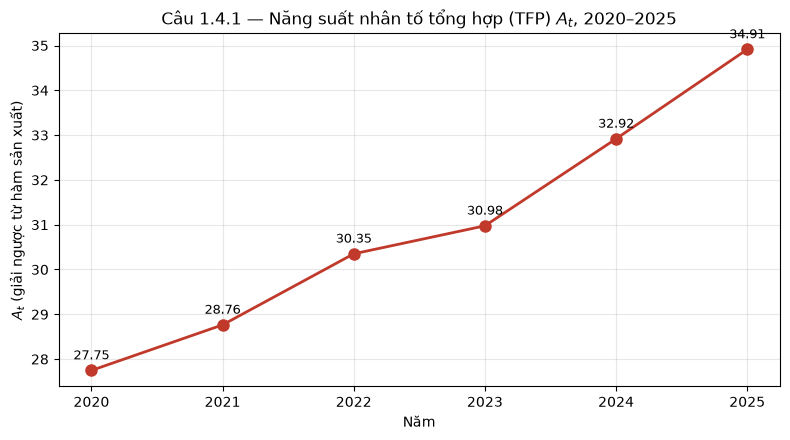


CÂU 1.4.2 — Dự báo Ŷ_t với A = trung bình A(2020-2025), tính MAPE
 Năm  Y thực tế  Ŷ dự báo  Sai số (%)
2020     8044.4    8971.5       11.53
2021     8487.5    9130.9        7.58
2022     9513.3    9699.6        1.96
2023    10221.8   10211.7        0.10
2024    11511.9   10822.0        5.99
2025    12847.6   11387.0       11.37

A trung bình (A_bar) = 30.9444
>>> MAPE = 6.42%


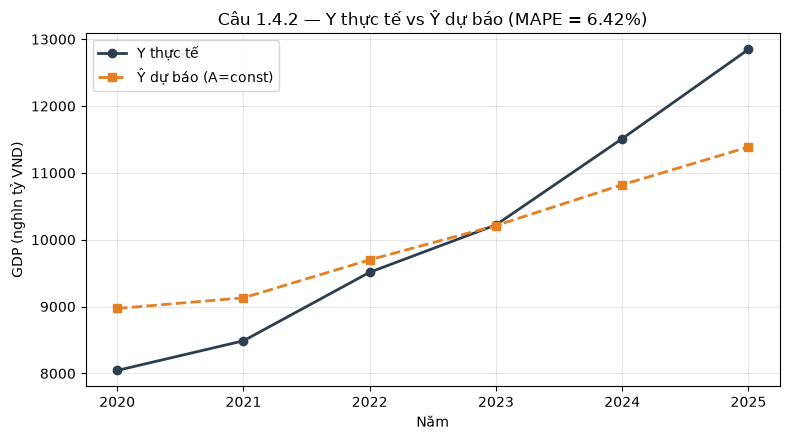


CÂU 1.4.3 — Phân rã tăng trưởng GDP bình quân năm, 2020-2025
          Yếu tố  Đóng góp (điểm %/năm)  Tỷ trọng (%)
K (vốn vật chất)                   2.98         31.78
    L (lao động)                  -0.03         -0.34
      D (số hóa)                   0.97         10.37
      AI (DN số)                   0.58          6.24
 H (nhân lực số)                   0.27          2.87
   TFP (phần dư)                   4.60         49.08
    TỔNG (Δln Y)                   9.36        100.00

Tăng trưởng GDP log bình quân ≈ 9.36%/năm


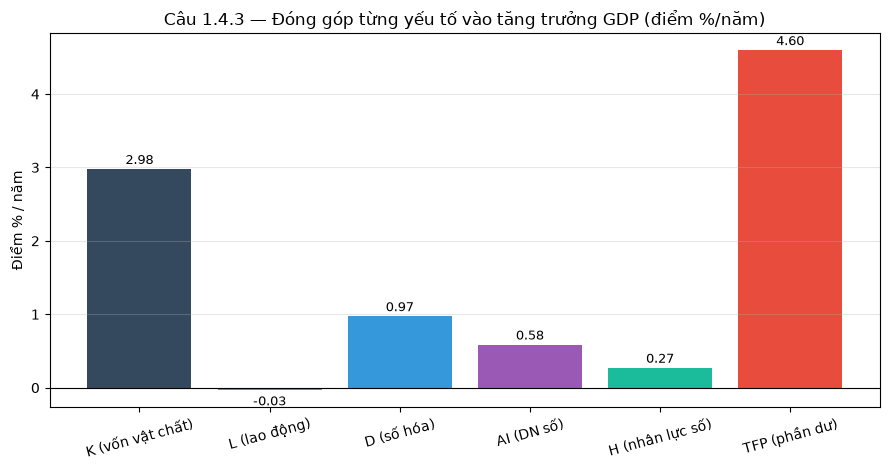


CÂU 1.4.4 — Dự báo GDP Việt Nam năm 2030 (kịch bản đề bài)
Giả định 2030: K=34,660 | L=71.5 | D=30% | AI=100 ngh.DN | H=35% | A=37.0593

>>> GDP dự báo 2030 ≈ 18,262.0 nghìn tỷ VND
    Tăng trưởng GDP bình quân 2025->2030 ≈ 7.29%/năm


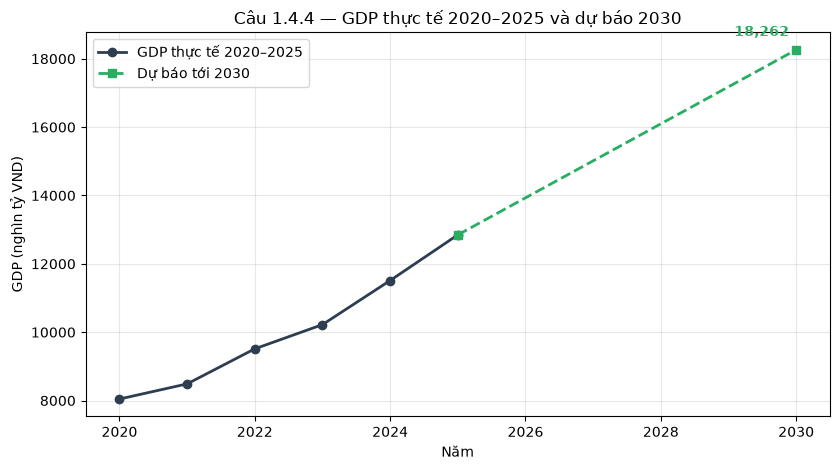


HOÀN TẤT BÀI 1 (Câu 1.4.1 -> 1.4.4)


In [1]:
# =====================================================================
# BÀI 1 - HÀM SẢN XUẤT COBB-DOUGLAS MỞ RỘNG VỚI AI VÀ SỐ HÓA
# Giải trọn vẹn Câu 1.4.1 -> 1.4.4 trong MỘT cell (Google Colab)
# Tác giả phân tích: chuyên gia OR & Data Science
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0. ĐỌC DỮ LIỆU
#    - Nếu đã upload file lên Colab, để nguyên 'vietnam_macro_2020_2025.csv'.
#    - Nếu chưa upload, đoạn try/except sẽ tự tạo dữ liệu từ Bảng 1.3 của đề.
# ---------------------------------------------------------------------
CSV_PATH = '../data/vietnam_macro_2020_2025.csv'
try:
    df = pd.read_csv(CSV_PATH).sort_values('year').reset_index(drop=True)
    print(f"Đã đọc dữ liệu từ '{CSV_PATH}'. Shape = {df.shape}")
except FileNotFoundError:
    print(f"Không tìm thấy '{CSV_PATH}' -> dùng dữ liệu nội suy từ Bảng 1.3 của đề.")
    df = pd.DataFrame({
        'year': [2020, 2021, 2022, 2023, 2024, 2025],
        'GDP_trillion_VND': [8044.4, 8487.5, 9513.3, 10221.8, 11511.9, 12847.6],
         'digital_economy_share_GDP_pct': [12.0,12.7,14.3,16.5,18.3,19.5],  # thêm dòng này
})
D_csv = df['digital_economy_share_GDP_pct'].values.astype(float)


# Các chuỗi đầu vào (theo Bảng 1.3 của đề bài) ------------------------
year = df['year'].values
K  = np.array([16500, 17800, 19600, 21300, 23500, 25900], dtype=float)  # vốn tích lũy (ngh.tỷ)
L  = np.array([53.6, 50.5, 51.7, 52.4, 52.9, 53.4], dtype=float)        # lao động (triệu)
D_csv = df['digital_economy_share_GDP_pct'].values.astype(float)
D  = D_csv.copy()   # KTS/GDP (%) — lấy thẳng từ cột digital_economy_share_GDP_pct
AI = np.array([55.6, 60.2, 65.4, 67.0, 73.8, 80.1], dtype=float)        # ngh. DN số
H  = np.array([24.1, 26.1, 26.2, 27.0, 28.4, 29.2], dtype=float)        # LĐ qua ĐT (%)
Y  = df['GDP_trillion_VND'].values.astype(float)                        # GDP thực tế (ngh.tỷ)

# Hệ số co giãn (tổng = 1 -> lợi suất không đổi theo quy mô) -----------
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07
assert abs(alpha + beta + gamma + delta + theta - 1.0) < 1e-9, "Tổng hệ số phải = 1"

# Hàm tiện ích tính lõi Cobb-Douglas K^a * L^b * D^g * AI^d * H^th -----
def cobb_core(K, L, D, AI, H):
    return (K**alpha) * (L**beta) * (D**gamma) * (AI**delta) * (H**theta)

# =====================================================================
# CÂU 1.4.1 — ƯỚC LƯỢNG TFP A_t (GIẢI NGƯỢC) VÀ VẼ XU HƯỚNG
# =====================================================================
print("\n" + "="*70)
print("CÂU 1.4.1 — Ước lượng năng suất nhân tố tổng hợp (TFP) A_t")
print("="*70)

core = cobb_core(K, L, D, AI, H)
A = Y / core                                  # giải ngược: A_t = Y_t / core_t

tab_141 = pd.DataFrame({'Năm': year, 'Y (GDP)': Y, 'Core CD': core.round(2), 'TFP A_t': A.round(4)})
print(tab_141.to_string(index=False))

# Tốc độ tăng TFP trung bình (CAGR)
tfp_cagr = (A[-1] / A[0])**(1/(len(A)-1)) - 1
print(f"\nTFP CAGR 2020-2025: {tfp_cagr*100:.2f}%/năm  |  A_2020={A[0]:.3f} -> A_2025={A[-1]:.3f}")

plt.figure(figsize=(8, 4.5))
plt.plot(year, A, 'o-', lw=2, color='#c0392b', markersize=8)
for xi, yi in zip(year, A):
    plt.annotate(f'{yi:.2f}', (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
plt.title('Câu 1.4.1 — Năng suất nhân tố tổng hợp (TFP) $A_t$, 2020–2025', fontsize=12)
plt.xlabel('Năm'); plt.ylabel('$A_t$ (giải ngược từ hàm sản xuất)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# =====================================================================
# CÂU 1.4.2 — DỰ BÁO Ŷ_t VỚI A = TRUNG BÌNH, BÁO CÁO MAPE
# =====================================================================
print("\n" + "="*70)
print("CÂU 1.4.2 — Dự báo Ŷ_t với A = trung bình A(2020-2025), tính MAPE")
print("="*70)

A_bar = A.mean()
Y_hat = A_bar * core
ape = np.abs((Y - Y_hat) / Y) * 100          # absolute percentage error mỗi năm
mape = ape.mean()

tab_142 = pd.DataFrame({
    'Năm': year,
    'Y thực tế': Y.round(1),
    'Ŷ dự báo': Y_hat.round(1),
    'Sai số (%)': ape.round(2)
})
print(tab_142.to_string(index=False))
print(f"\nA trung bình (A_bar) = {A_bar:.4f}")
print(f">>> MAPE = {mape:.2f}%")

plt.figure(figsize=(8, 4.5))
plt.plot(year, Y, 'o-', lw=2, label='Y thực tế', color='#2c3e50')
plt.plot(year, Y_hat, 's--', lw=2, label='Ŷ dự báo (A=const)', color='#e67e22')
plt.title(f'Câu 1.4.2 — Y thực tế vs Ŷ dự báo (MAPE = {mape:.2f}%)', fontsize=12)
plt.xlabel('Năm'); plt.ylabel('GDP (nghìn tỷ VND)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# =====================================================================
# CÂU 1.4.3 — PHÂN RÃ TĂNG TRƯỞNG (GROWTH ACCOUNTING) 2020-2025
#   Δln Y = Δln A + αΔln K + βΔln L + γΔln D + δΔln AI + θΔln H
# =====================================================================
print("\n" + "="*70)
print("CÂU 1.4.3 — Phân rã tăng trưởng GDP bình quân năm, 2020-2025")
print("="*70)

# Tăng trưởng log bình quân năm = (lnX_2025 - lnX_2020) / số năm
n = len(year) - 1
def avg_dln(x):
    return (np.log(x[-1]) - np.log(x[0])) / n

dlnY  = avg_dln(Y)
dlnK  = avg_dln(K)
dlnL  = avg_dln(L)
dlnD  = avg_dln(D)
dlnAI = avg_dln(AI)
dlnH  = avg_dln(H)

contrib = {
    'K (vốn vật chất)'   : alpha * dlnK,
    'L (lao động)'       : beta  * dlnL,
    'D (số hóa)'         : gamma * dlnD,
    'AI (DN số)'         : delta * dlnAI,
    'H (nhân lực số)'    : theta * dlnH,
}
contrib['TFP (phần dư)'] = dlnY - sum(contrib.values())   # Solow residual

tot = sum(contrib.values())                               # = dlnY
tab_143 = pd.DataFrame({
    'Yếu tố': list(contrib.keys()),
    'Đóng góp (điểm %/năm)': [v*100 for v in contrib.values()],
    'Tỷ trọng (%)': [v/tot*100 for v in contrib.values()],
})
tab_143 = pd.concat([tab_143, pd.DataFrame({
    'Yếu tố': ['TỔNG (Δln Y)'],
    'Đóng góp (điểm %/năm)': [tot*100],
    'Tỷ trọng (%)': [100.0]
})], ignore_index=True)
pd.options.display.float_format = '{:.2f}'.format
print(tab_143.to_string(index=False))
print(f"\nTăng trưởng GDP log bình quân ≈ {dlnY*100:.2f}%/năm")

# Biểu đồ cột đóng góp
keys = list(contrib.keys())
vals = [contrib[k]*100 for k in keys]
colors = ['#34495e', '#7f8c8d', '#3498db', '#9b59b6', '#1abc9c', '#e74c3c']
plt.figure(figsize=(9, 4.8))
bars = plt.bar(keys, vals, color=colors)
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v + (0.03 if v >= 0 else -0.08),
             f'{v:.2f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
plt.axhline(0, color='black', lw=0.8)
plt.title('Câu 1.4.3 — Đóng góp từng yếu tố vào tăng trưởng GDP (điểm %/năm)', fontsize=12)
plt.ylabel('Điểm % / năm'); plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

# =====================================================================
# CÂU 1.4.4 — MÔ PHỎNG & DỰ BÁO GDP 2030
#   D->30%, AI->100 ngh.DN, H->35%; K,L tăng 6%/năm; TFP tăng 1,2%/năm
# =====================================================================
print("\n" + "="*70)
print("CÂU 1.4.4 — Dự báo GDP Việt Nam năm 2030 (kịch bản đề bài)")
print("="*70)

base_year = 2025
n_fwd = 2030 - base_year                       # 5 năm

K_2030  = K[-1]  * (1.06)**n_fwd               # K tăng 6%/năm từ giá trị 2025
L_2030  = L[-1]  * (1.06)**n_fwd               # L tăng 6%/năm
D_2030  = 30.0                                 # KTS/GDP = 30%
AI_2030 = 100.0                                # 100 nghìn DN số
H_2030  = 35.0                                 # 35% LĐ qua đào tạo
A_2030  = A[-1] * (1.012)**n_fwd               # TFP tăng 1,2%/năm từ A_2025

Y_2030 = A_2030 * cobb_core(K_2030, L_2030, D_2030, AI_2030, H_2030)

print(f"Giả định 2030: K={K_2030:,.0f} | L={L_2030:.1f} | D={D_2030:.0f}% | "
      f"AI={AI_2030:.0f} ngh.DN | H={H_2030:.0f}% | A={A_2030:.4f}")
print(f"\n>>> GDP dự báo 2030 ≈ {Y_2030:,.1f} nghìn tỷ VND")
print(f"    Tăng trưởng GDP bình quân 2025->2030 ≈ "
      f"{((Y_2030/Y[-1])**(1/n_fwd)-1)*100:.2f}%/năm")

# Vẽ đường lịch sử + điểm dự báo 2030
plt.figure(figsize=(8.5, 4.8))
plt.plot(year, Y, 'o-', lw=2, color='#2c3e50', label='GDP thực tế 2020–2025')
plt.plot([2025, 2030], [Y[-1], Y_2030], 's--', lw=2, color='#27ae60', label='Dự báo tới 2030')
plt.annotate(f'{Y_2030:,.0f}', (2030, Y_2030), textcoords="offset points",
             xytext=(-5, 10), ha='right', fontsize=10, color='#27ae60', fontweight='bold')
plt.title('Câu 1.4.4 — GDP thực tế 2020–2025 và dự báo 2030', fontsize=12)
plt.xlabel('Năm'); plt.ylabel('GDP (nghìn tỷ VND)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*70)
print("HOÀN TẤT BÀI 1 (Câu 1.4.1 -> 1.4.4)")
print("="*70)